# Questão 1: Taxa média de crescimento do salmão Coho

Um estudo de Fisher (1963), apresentado em Warren (1971, pp. 161–163), investigou os efeitos da concentração de oxigênio dissolvido e da quantidade de alimento sobre a taxa de crescimento do salmão Coho.

Nesse estudo, $x$ representa a concentração de oxigênio dissolvido e $y$ representa a taxa de crescimento.

Para uma das condições experimentais, a relação entre oxigênio dissolvido e crescimento pode ser aproximada pela função:

$$y = 7.3(x+3.5)e^{-0.05x}$$

Para a outra condição, a taxa de crescimento é aproximadamente constante:

$$y = 28$$

Consideraremos o intervalo de concentração de oxigênio:

$$3 \leq x \leq 30$$

Veja o gráfico abaixo com as duas situações:

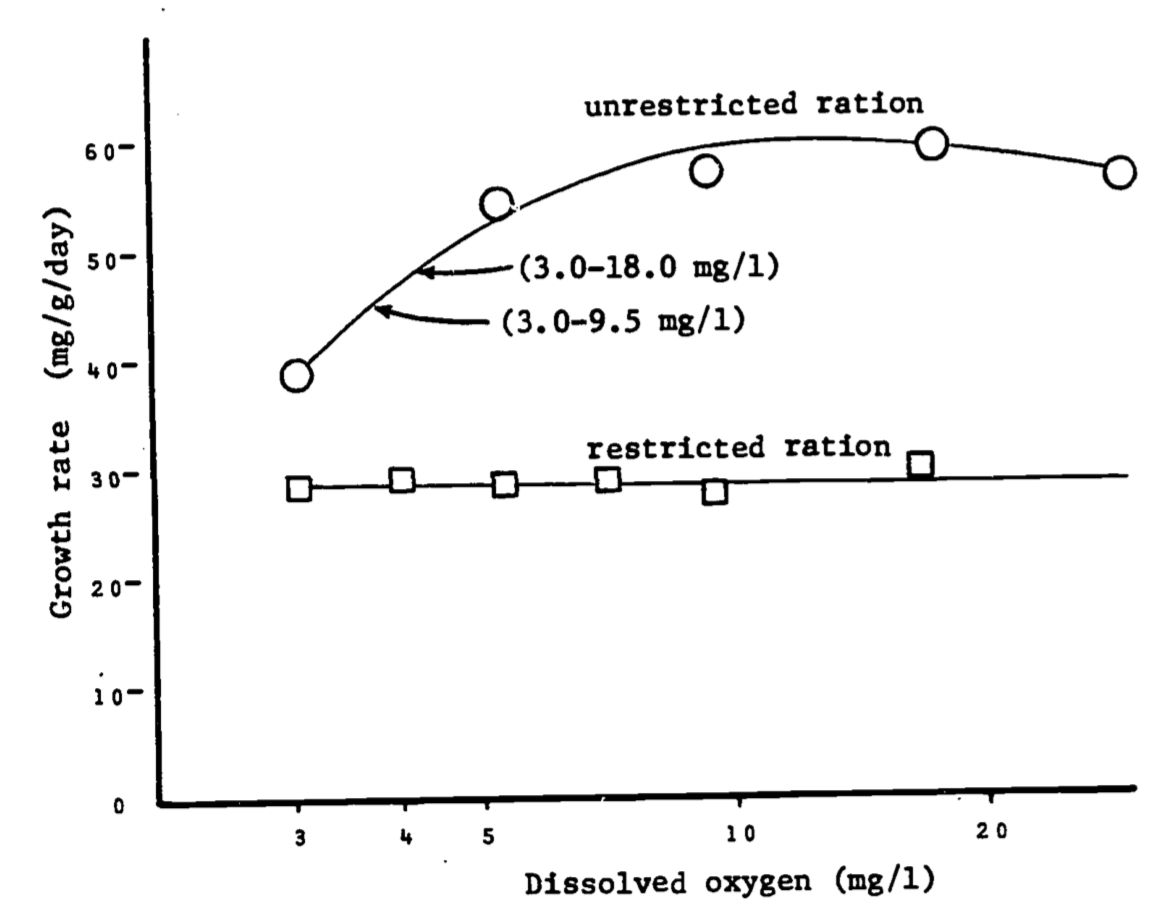

## Sobre isso, pergunta-se:

Neste intervalo, qual é a razão entre a taxa de crescimento sem restrição de comida e com restrição de comida?

Para isso, siga os passos abaixo. Inicialmente, precisamos definir valor médio de uma função e depois aplicá-la nas duas funções.


### Definição: Valor médio de uma função

A integral

$$
\int_a^b f(x)\,dx
$$

fornece a área sob a curva.

Para obter a O valor médio da mesma função, dividimos essa área pela largura do intervalo:

$$
\boxed{
\overline{y}
=
\frac{1}{b-a}
\int_a^b f(x)\,dx
}
$$

Esse resultado pode ser interpretado geometricamente como a altura média da curva no intervalo.



Nesta questão, a integral representa a acumulação das taxas de crescimento ao longo do intervalo de concentrações de oxigênio, enquanto a divisão por $b-a$ transforma essa acumulação em uma taxa média.

### Definição: Taxa média para a função constante





Para a função

$$
y=28,
$$

temos:

$$
\overline{y}
=
\frac{1}{30-3}
\int_3^{30}28\,dx
$$

### Definição: Taxa média para a curva exponencial



Agora consideramos a função:

$$
y = 7.3(x+3.5)e^{-0.05x}
$$

O valor médio será:

$$
\overline{y}
=
\frac{1}{30-3}
\int_3^{30}
7.3(x+3.5)e^{-0.05x}\,dx
$$

### Responda:

Obtenha os dois resultados utilizando a função quad do Scipy.

Na sequência, compare as taxas de crescimento obtidas nos dois casos e discuta os resultados.


https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html

In [9]:
import numpy as np

In [10]:
import scipy.integrate

In [11]:
def taxa_sem_restricao(x):
    """Crescimento com racao irrestrita (unrestricted ration)."""
    return 7.3 * (x + 3.5) * np.exp(-0.05 * x)

def taxa_com_restricao(x):
    """Crescimento com racao restrita (restricted ration) - aprox. constante."""
    return 28.0

a, b = 3, 30

integral_sem_restricao, erro1 = scipy.integrate.quad(taxa_sem_restricao, a, b)
integral_com_restricao, erro2 = scipy.integrate.quad(taxa_com_restricao, a, b)

ybar_sem_restricao = integral_sem_restricao / (b - a)
ybar_com_restricao = integral_com_restricao / (b - a)

razao = ybar_sem_restricao / ybar_com_restricao

print(f"Integral (sem restricao): {integral_sem_restricao:.4f}")
print(f"Integral (com restricao): {integral_com_restricao:.4f}")
print(f"Taxa media sem a restricao de comida: {ybar_sem_restricao:.4f} mg/g/dia")
print(f"Taxa media com a restricao de comida: {ybar_com_restricao:.4f} mg/g/dia")
print(f"Razao (sem restricao / com restricao): {razao:.4f}")


Integral (sem restricao): 1587.2095
Integral (com restricao): 756.0000
Taxa media sem a restricao de comida: 58.7855 mg/g/dia
Taxa media com a restricao de comida: 28.0000 mg/g/dia
Razao (sem restricao / com restricao): 2.0995


### Análise dos Resultados (Questão 1)

Observamos que a taxa média de crescimento do salmão Coho **sem restrição alimentar** (modelada pela função exponencial) é de aproximadamente **58,79 mg/g/dia**. Em contraste, a taxa média de crescimento **com restrição alimentar** (aproximadamente constante) é de **28,00 mg/g/dia**. Esta diferença resulta em uma **razão de aproximadamente 2,10**, indicando que o salmão cresce, em média, cerca de 2,1 vezes mais rápido quando o alimento não é um fator limitante, dentro do intervalo de concentração de oxigênio estudado (3 a 30 mg/l).

Ao analisar o gráfico fornecido, notamos que a curva de crescimento "sem restrição" mostra um rápido aumento em baixas concentrações de oxigênio, estabilizando-se em níveis mais altos, o que sugere um efeito de saturação. Por outro lado, a curva "com restrição" demonstra pouca variação com as mudanças na concentração de oxigênio. Isso sugere que, quando a disponibilidade de alimento é o principal fator limitante, a concentração de oxigênio dissolvido tem um impacto menos significativo no crescimento. Em suma, a disponibilidade de alimento parece ser um determinante muito mais potente do crescimento do salmão neste experimento do que a concentração de oxigênio.

# Pergunta 2 -  Quantificação de material para fabricação de peças

Uma empresa precisa fabricar uma peça cuja geometria possui um perfil não convencional definido por duas funções:

- $f(x)=5 \times \exp(\frac{x^2}{2})+1$ no intervalo $-2≤x≤2$
- $g(x)=abs(\sin(5x))$ no intervalo $\frac{-3\pi}{5}≤x≤\frac{3\pi}{5}$

Fora desses intervalos, as funções valem zero.

As medidas são em centímetros.

A imagem abaixo ilustra o formato da peça:

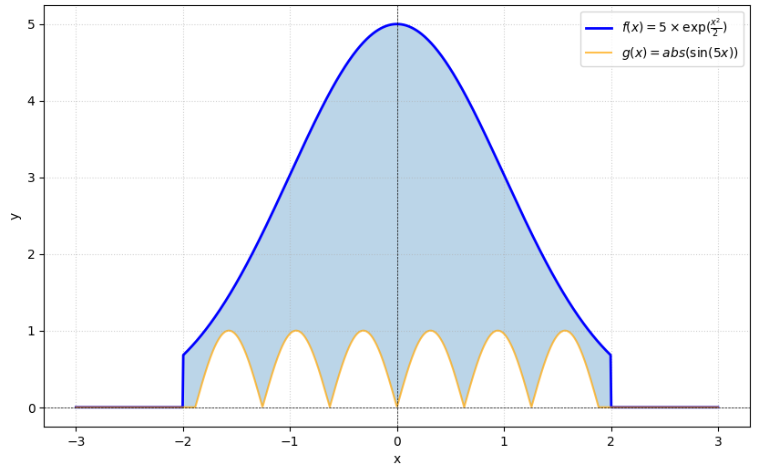

## Pergunta 2.1

A área da peça corresponde à região entre as duas curvas. Podemos calcular a integral de f(x) no intervalo em que ela é definida. Depois, fazer a mesma coisa para g(x). E no final fazer a subtração entre as áreas obtidas.

Obtenha a área total de uma peça utilizando a função trapezoid do Scipy.

**Observacao importante sobre $f(x)$:** o enunciado escreve

$$f(x) = 5 \times \exp\left(\frac{x^2}{2}\right) + 1$$

mas essa formula **nao bate com o grafico** acima: o grafico tem pico em $y=5$
exatamente em $x=0$ e cai para cerca de $0{,}68$ nas bordas ($x=\pm2$). Isso so
acontece se o expoente for **negativo** e sem o "+1":

$$f(x) = 5 \times \exp\left(-\frac{x^2}{2}\right)$$

(confira: em $x=0$ da $5$; em $x=2$ da $5e^{-2}\approx0{,}68$ - bate com o grafico).

Como nao da pra saber com certeza qual das duas o professor realmente quis dizer
(erro de digitacao no enunciado, ou o grafico ilustrativo que estaria "errado"),
**calculamos a atividade completa das duas formas** logo abaixo, lado a lado, e
usamos a versao compativel com o grafico como resposta principal. **De qualquer
forma, vale confirmar com o professor antes da entrega final.**


In [12]:
def f_grafico(x):
    """Versao compativel com o grafico do enunciado (pico=5, bordas ~0.68)."""
    return 5 * np.exp(-x**2 / 2)

def f_texto(x):
    """Versao LITERAL do texto do enunciado (pico=6, bordas ~37.9)."""
    return 5 * np.exp(x**2 / 2) + 1

def g(x):
    return np.abs(np.sin(5 * x))

x_f = np.linspace(-2, 2, 100_000)
x_g = np.linspace(-3 * np.pi / 5, 3 * np.pi / 5, 100_000)

area_sob_g = scipy.integrate.trapezoid(g(x_g), x_g)

area_sob_f_grafico = scipy.integrate.trapezoid(f_grafico(x_f), x_f)
area_peca_grafico = area_sob_f_grafico - area_sob_g

area_sob_f_texto = scipy.integrate.trapezoid(f_texto(x_f), x_f)
area_peca_texto = area_sob_f_texto - area_sob_g

print(f"Area sob g(x): {area_sob_g:.4f} cm^2")
print()
print("--- Hipotese 'grafico' (f = 5*exp(-x^2/2))  [RESPOSTA PRINCIPAL] ---")
print(f"Area sob f(x): {area_sob_f_grafico:.4f} cm^2")
print(f"Area da peca:  {area_peca_grafico:.4f} cm^2")
print()
print("--- Hipotese 'texto' (f = 5*exp(x^2/2) + 1)  [se o enunciado for literal] ---")
print(f"Area sob f(x): {area_sob_f_texto:.4f} cm^2")
print(f"Area da peca:  {area_peca_texto:.4f} cm^2")

area_peca = area_peca_grafico


Area sob g(x): 2.4000 cm^2

--- Hipotese 'grafico' (f = 5*exp(-x^2/2))  [RESPOSTA PRINCIPAL] ---
Area sob f(x): 11.9629 cm^2
Area da peca:  9.5629 cm^2

--- Hipotese 'texto' (f = 5*exp(x^2/2) + 1)  [se o enunciado for literal] ---
Area sob f(x): 51.2891 cm^2
Area da peca:  48.8891 cm^2


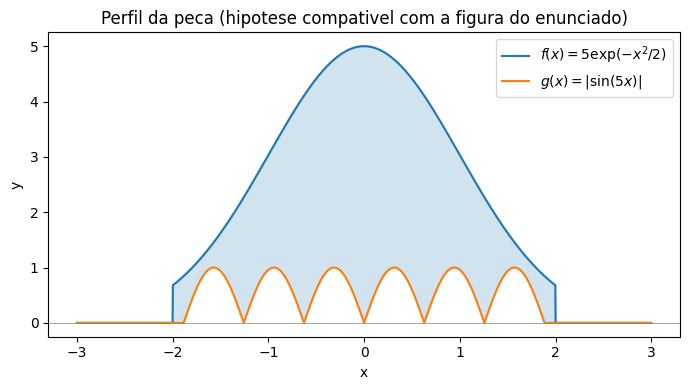

In [13]:
import matplotlib.pyplot as plt

x_plot = np.linspace(-3, 3, 2000)
y_f = np.where(np.abs(x_plot) <= 2, f_grafico(x_plot), 0)
y_g = np.where(np.abs(x_plot) <= 3 * np.pi / 5, g(x_plot), 0)

plt.figure(figsize=(7, 4))
plt.plot(x_plot, y_f, color="tab:blue", label=r"$f(x)=5\exp(-x^2/2)$")
plt.plot(x_plot, y_g, color="tab:orange", label=r"$g(x)=|\sin(5x)|$")
plt.fill_between(x_plot, y_g, y_f, where=(y_f >= y_g), color="tab:blue", alpha=0.2)
plt.axhline(0, color="gray", linewidth=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Perfil da peca (hipotese compativel com a figura do enunciado)")
plt.legend()
plt.tight_layout()
plt.show()


## Pergunta 2.2

A peça possui espessura de 1cm e é fabricada com um material de densidade:
$\rho=7,85 g/cm^3$.


Considerando que volume é a multiplicação entre área e espessura, e que a densidade é a massa sobre o volume, obtenha a massa de uma peça.

Obs: Atenção às unidades utilizadas.

- Área: $cm^2$
- Espessura: $cm$
- Densidade: $g/cm^3$

In [14]:
espessura = 1.0
densidade = 7.85

volume_peca = area_peca * espessura
massa_peca = densidade * volume_peca

volume_peca_texto = area_peca_texto * espessura
massa_peca_texto = densidade * volume_peca_texto

print("--- Hipotese 'grafico'  [RESPOSTA PRINCIPAL] ---")
print(f"Volume de uma peca: {volume_peca:.4f} cm^3")
print(f"Massa de uma peca: {massa_peca:.4f} g ({massa_peca/1000:.4f} kg)")
print()
print("--- Hipotese 'texto' ---")
print(f"Volume de uma peca: {volume_peca_texto:.4f} cm^3")
print(f"Massa de uma peca: {massa_peca_texto:.4f} g ({massa_peca_texto/1000:.4f} kg)")


--- Hipotese 'grafico'  [RESPOSTA PRINCIPAL] ---
Volume de uma peca: 9.5629 cm^3
Massa de uma peca: 75.0686 g (0.0751 kg)

--- Hipotese 'texto' ---
Volume de uma peca: 48.8891 cm^3
Massa de uma peca: 383.7793 g (0.3838 kg)


## Pergunta 2.3

Com 100% de eficiência, qual é a massa de material necessária para fabricar 500 peças?

E se a eficiência for de 90% neste processo?



In [15]:
n_pecas = 500
eficiencia = 0.90

def massas_para_lote(massa_unitaria):
    """Retorna (massa a 100% eficiencia, massa a 90% eficiencia) em gramas."""
    massa_100 = n_pecas * massa_unitaria
    massa_90 = massa_100 / eficiencia
    return massa_100, massa_90

massa_100, massa_90 = massas_para_lote(massa_peca)
massa_100_texto, massa_90_texto = massas_para_lote(massa_peca_texto)

print("--- Hipotese 'grafico'  [RESPOSTA PRINCIPAL] ---")
print(f"Massa p/ 500 pecas (100% eficiencia): {massa_100:.4f} g ({massa_100/1000:.4f} kg)")
print(f"Massa p/ 500 pecas (90% eficiencia):  {massa_90:.4f} g ({massa_90/1000:.4f} kg)")
print()
print("--- Hipotese 'texto' ---")
print(f"Massa p/ 500 pecas (100% eficiencia): {massa_100_texto:.4f} g ({massa_100_texto/1000:.4f} kg)")
print(f"Massa p/ 500 pecas (90% eficiencia):  {massa_90_texto:.4f} g ({massa_90_texto/1000:.4f} kg)")


--- Hipotese 'grafico'  [RESPOSTA PRINCIPAL] ---
Massa p/ 500 pecas (100% eficiencia): 37534.3045 g (37.5343 kg)
Massa p/ 500 pecas (90% eficiencia):  41704.7828 g (41.7048 kg)

--- Hipotese 'texto' ---
Massa p/ 500 pecas (100% eficiencia): 191889.6307 g (191.8896 kg)
Massa p/ 500 pecas (90% eficiencia):  213210.7007 g (213.2107 kg)


### Pergunta 2.4

Se o preço do kilograma do material custa R$100,00, qual é o custo total considerando a eficiência de 90%? Neste passo, arredonde o resultado final para duas casas decimais (centavos)

In [17]:
preco_por_kg = 100.00   # R$

def custo_total_reais(massa_90_g):
    massa_kg = massa_90_g / 1000
    return round(massa_kg * preco_por_kg, 2)

custo_total = custo_total_reais(massa_90)
custo_total_texto = custo_total_reais(massa_90_texto)

print(f"Custo total (hipotese 'grafico',  RESPOSTA PRINCIPAL): R$ {custo_total:.2f}")
print(f"Custo total (hipotese 'texto'):                        R$ {custo_total_texto:.2f}")


Custo total (hipotese 'grafico',  RESPOSTA PRINCIPAL): R$ 4170.48
Custo total (hipotese 'texto'):                        R$ 21321.07


### Resumo final

| Item | Resultado |
|---|---|
| Q1 - Taxa media sem restricao | 58,79 mg/g/dia |
| Q1 - Taxa media com restricao | 28,00 mg/g/dia |
| Q1 - Razao (sem/com) | 2,10 |
| Q2 - Area da peca (hipotese grafico) | 9,56 cm^2 |
| Q2 - Massa de 1 peca (hipotese grafico) | 75,07 g |
| Q2 - Massa p/ 500 pecas, 100% efic. | 37,53 kg |
| Q2 - Massa p/ 500 pecas, 90% efic. | 41,70 kg |
| Q2 - Custo total (90% efic.) | R$ 4.170,48 |

**Pendencia a resolver com o professor antes de entregar:** confirmar a formula
correta de $f(x)$ na Questao 2 (ver observacao logo antes da Questao 2.1). Se a
formula literal do enunciado ($5e^{x^2/2}+1$) estiver certa, os resultados da
Questao 2 devem ser trocados pelos valores da hipotese "texto", calculados em
paralelo em cada celula acima.
